# Import the relevant libraries

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
# We can override the default matplotlib styles with those of Seaborn
sns.set()
from sklearn.linear_model import LinearRegression

# Load the data

In [2]:
data = pd.read_csv('simple_linear_regression.csv')
data.head()

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83


# Declare the dependent and the independent variables

In [11]:
x = data['SAT'] # Independent variable
print(x)
y = data['SAT']
print(y)
y = data['GPA'] # Dependent variable

0     1714
1     1664
2     1760
3     1685
4     1693
      ... 
79    1936
80    1810
81    1987
82    1962
83    2050
Name: SAT, Length: 84, dtype: int64
0     1714
1     1664
2     1760
3     1685
4     1693
      ... 
79    1936
80    1810
81    1987
82    1962
83    2050
Name: SAT, Length: 84, dtype: int64


In [4]:
x.shape

(84,)

In [5]:
y.shape

(84,)

# We need to reshape x to be a 2D array, as required by scikit-learn

In [13]:
x_reshaped = x.values.reshape(-1,1)

In [14]:
y_reshaped = y.values.reshape(-1,1)
print(y_reshaped)

[[2.4 ]
 [2.52]
 [2.54]
 [2.74]
 [2.83]
 [2.91]
 [3.  ]
 [3.  ]
 [3.01]
 [3.01]
 [3.02]
 [3.07]
 [3.08]
 [3.08]
 [3.12]
 [3.17]
 [3.17]
 [3.17]
 [3.17]
 [3.19]
 [3.19]
 [3.19]
 [3.2 ]
 [3.21]
 [3.24]
 [3.28]
 [3.28]
 [3.28]
 [3.28]
 [3.28]
 [3.28]
 [3.28]
 [3.29]
 [3.29]
 [3.29]
 [3.31]
 [3.32]
 [3.34]
 [3.37]
 [3.37]
 [3.37]
 [3.38]
 [3.38]
 [3.39]
 [3.39]
 [3.4 ]
 [3.4 ]
 [3.4 ]
 [3.41]
 [3.41]
 [3.41]
 [3.42]
 [3.42]
 [3.42]
 [3.44]
 [3.47]
 [3.47]
 [3.47]
 [3.47]
 [3.48]
 [3.49]
 [3.49]
 [3.5 ]
 [3.51]
 [3.51]
 [3.52]
 [3.52]
 [3.54]
 [3.58]
 [3.58]
 [3.59]
 [3.59]
 [3.6 ]
 [3.6 ]
 [3.61]
 [3.62]
 [3.64]
 [3.65]
 [3.71]
 [3.71]
 [3.71]
 [3.73]
 [3.76]
 [3.81]]


# Regression

In [15]:
regression = LinearRegression()

In [35]:
regression.fit(x_reshaped, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# R-squared

In [34]:
regression.score(x_reshaped, y)

0.40600391479679765

# Coefficients

In [21]:
regression.coef_

array([0.00165569])

# Intercept

In [22]:
regression.intercept_

np.float64(0.27504029966028076)

# Predicting values

In [23]:
regression.predict([[1700]])

array([3.08970998])

In [31]:
new_data = pd.DataFrame(data=[1700, 1790], columns=['SAT'])
new_data

,SAT
0,1700
1,1790


In [38]:
new_data['Predict_GPA'] = regression.predict(new_data)
new_data

C:\shiva\coding\python_projects\dear_comrade_data_science_zero_to_hero\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


,SAT,Predict_GPA
0,1700,3.089710
1,1790,3.238722


# Plotting the regression line

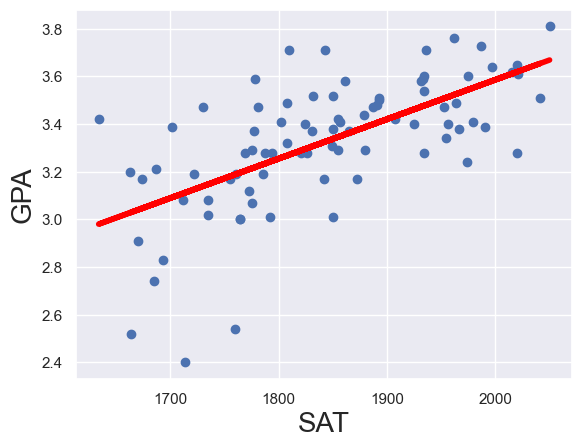

In [42]:
plt.scatter(x,y)
y_hat = regression.coef_ * x_reshaped + regression.intercept_
plt.plot(x, y_hat, lw=4, color='red', label='Regression Line')
plt.xlabel('SAT', fontsize=20)
plt.ylabel('GPA', fontsize=20)
plt.show()